# A/B Test Planning and Results Analysis

An entertainment app with an infinite feed uses two monetization models: a monthly paid subscription for ad-free content and advertising shown to users without a subscription.
The recommendation systems team has developed a new algorithm that they expect to show users more interesting content.
The objective of this study is to calculate the A/B test parameters needed to test this hypothesis and analyze the experiment results

## Data Description

The study uses three tables:

- `sessions_project_history.csv` — historical user session data for August 15–September 23, 2025.
- `sessions_project_test_part.csv` — data for the first day of the A/B test, October 14, 2025.
- `sessions_project_test.csv` — data for the full A/B test period, October 14–November 2, 2025.

The tables share a common structure. The historical data does not include the experiment group column.

Column descriptions:

- `user_id` — user identifier;
- `session_id` — session identifier;
- `session_date` — session date;
- `session_start_ts` — session start date and time;
- `install_date` — app installation date;
- `session_number` — the user's session sequence number;
- `registration_flag` — user registration indicator;
- `page_counter` — number of pages viewed during a session;
- `region` — user region;
- `device` — device type;
- `test_group` — experiment group; absent from the historical data.

## Research Objectives

Calculate the A/B test parameters, check that the experiment was conducted correctly, and analyze its results.

### 1. Historical Data Analysis (EDA)

#### 1.1. Loading Historical Data
First, we will work with the app's historical data:

- Import the pandas library.

- Read the historical user session CSV file `sessions_project_history.csv` into the `sessions_history` DataFrame.

- Display the first five rows of the resulting DataFrame.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.stats.proportion import proportions_ztest

In [2]:
sessions_history = pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_history.csv')

In [3]:
sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


#### 1.2. Exploring the Data

We will calculate the number of unique sessions for each user. We will then examine the data for the user with the most sessions to explore the table structure and the values in its columns.

Calculate the number of unique sessions `session_id` for each unique user `user_id`:

In [4]:
sessions_per_user = sessions_history.groupby('user_id', as_index=False).agg(sessions_count=('session_id', 'nunique'))
sessions_per_user 

,user_id,sessions_count
0,00005FB6A13A6FBE,2
1,0000B15A18D77ED9,3
2,0000C4E3A4A571A9,2
3,000293FAF9E67A81,4
4,00029C5AE889A6C3,2
...,...,...
134034,FFFCDE7746148710,4
134035,FFFDD413285E753F,3
134036,FFFECBA0F2578AB0,2
134037,FFFEDB68228B5F21,5


Find the user with the highest number of sessions:

In [5]:
max_user = sessions_per_user.loc[
    sessions_per_user['sessions_count'].idxmax(),
    'user_id'
]
max_user

'10E0DEFC1ABDBBE0'

Display the data for the user with the highest number of sessions:

In [6]:
sessions_history[
    sessions_history['user_id'] == max_user
]

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


#### 1.3. Registration Count Analysis

We will examine daily trends in active users and registrations, as well as the share of registrations among active users.

For these calculations, we use the assumption specified in the study brief: a user has no more than one session per day, and their registration status does not change within a day. According to the brief, a registration is counted on the day it occurs.

First, we will inspect the data types and convert the `session_date` column to a date format. We will then calculate the daily metrics and plot their trends.

Display information about the `sessions_history` DataFrame:

In [7]:
sessions_history.info()

<class 'pandas.DataFrame'>
RangeIndex: 435924 entries, 0 to 435923
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   user_id            435924 non-null  str  
 1   session_id         435924 non-null  str  
 2   session_date       435924 non-null  str  
 3   session_start_ts   435924 non-null  str  
 4   install_date       435924 non-null  str  
 5   session_number     435924 non-null  int64
 6   registration_flag  435924 non-null  int64
 7   page_counter       435924 non-null  int64
 8   region             435924 non-null  str  
 9   device             435924 non-null  str  
dtypes: int64(3), str(7)
memory usage: 33.3 MB


Convert session_date to a date format:

In [8]:
sessions_history['session_date'] = pd.to_datetime(
    sessions_history['session_date']
)

Calculate the number of unique users per day:

In [9]:
daily_sessions = sessions_history.groupby('session_date', as_index=False).agg(users_count=('user_id', 'nunique'))

Calculate the number of unique registrations:

In [10]:
daily_registrations = (
    sessions_history
    .groupby('session_date', as_index=False)
    .agg(
        registrations_count=('registration_flag', 'sum')
    )
)

Plot the daily number of users and registrations:

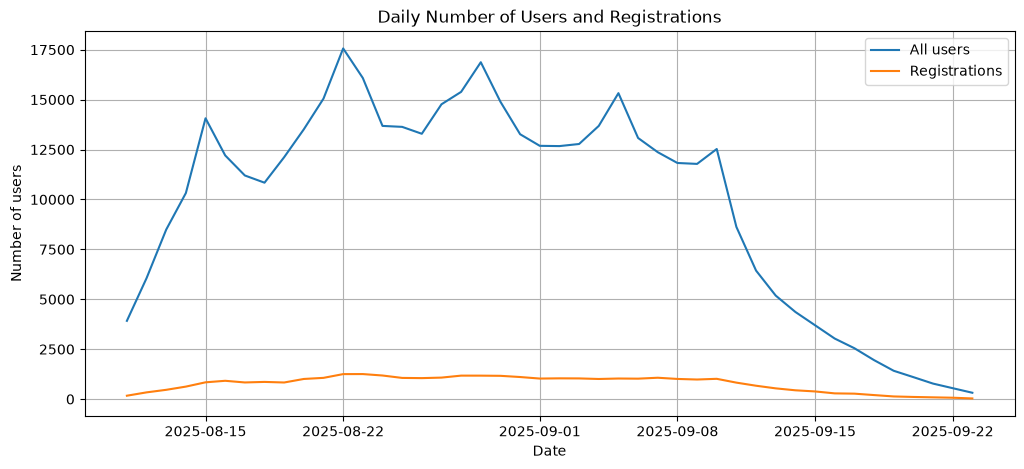

In [11]:
plt.figure(figsize=(12,5))

plt.plot(
    daily_sessions['session_date'],
    daily_sessions['users_count'],
    label='All users'
)

plt.plot(
    daily_registrations['session_date'],
    daily_registrations['registrations_count'],
    label='Registrations'
)

plt.title('Daily Number of Users and Registrations')
plt.xlabel('Date')
plt.ylabel('Number of users')

plt.grid()
plt.legend()

plt.show()

Merge the `daily_sessions` and `daily_registrations` DataFrames:

In [12]:
daily_metrics = daily_sessions.merge(
    daily_registrations,
    on='session_date',
    how='left'
)

Create a new column, `registration_share`:

In [13]:
daily_metrics['registration_share'] = (
    daily_metrics['registrations_count'] /
    daily_metrics['users_count']
)

Plot the daily share of registered users:

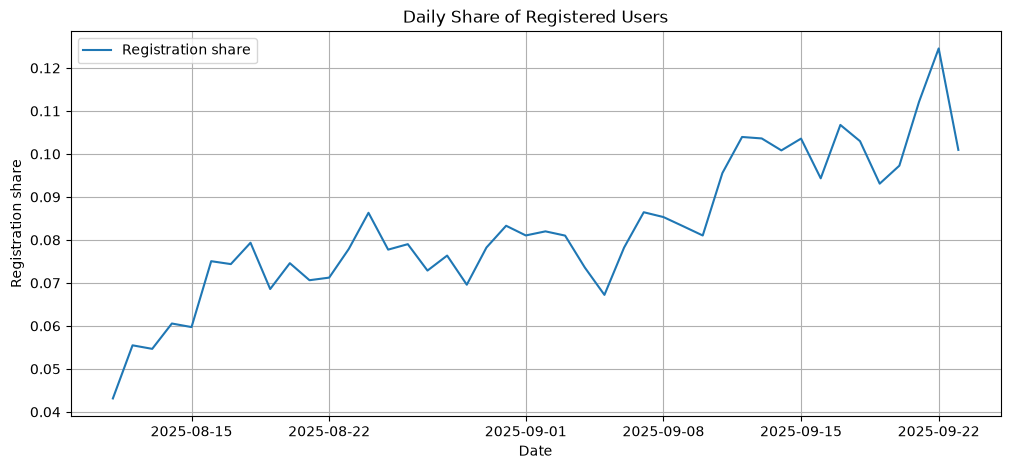

In [14]:
plt.figure(figsize=(12,5))

plt.plot(
    daily_metrics['session_date'],
    daily_metrics['registration_share'],
    label='Registration share'
)

plt.title('Daily Share of Registered Users')
plt.xlabel('Date')
plt.ylabel('Registration share')

plt.grid()
plt.legend()

plt.show()

#### 1.4. Page View Count Analysis

The number of pages viewed characterizes the depth of a user's interaction with content.

We will examine the distribution of this metric during users' first sessions: calculate the number of first sessions for each `page_counter` value and create a bar chart.

Filter for first sessions:

In [15]:
first_sessions = sessions_history[
    sessions_history['session_number'] == 1
]

Count the number of sessions for each page_counter value:

In [16]:
pages_distribution = first_sessions['page_counter'].value_counts()
pages_distribution

page_counter
3    50939
4    32739
2    32494
1     8978
5     8075
6      777
7       37
Name: count, dtype: int64

Create a bar chart:

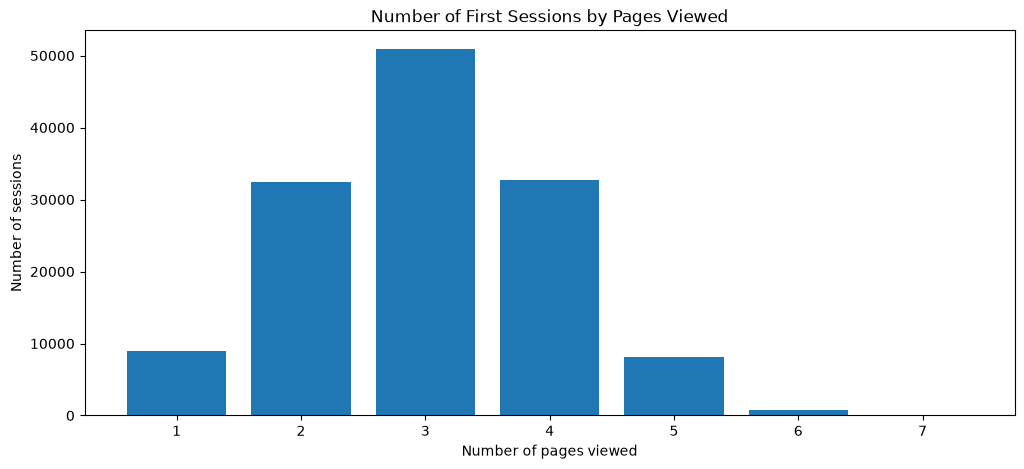

In [17]:
plt.figure(figsize=(12,5))

plt.bar(
    pages_distribution.index,
    pages_distribution.values
)

plt.title('Number of First Sessions by Pages Viewed')
plt.xlabel('Number of pages viewed')
plt.ylabel('Number of sessions')

plt.show()

#### 1.5. Share of Users Viewing Four or More Pages in Their First Session

The product team considers viewing four or more pages in the first session a proxy indicator of user engagement.

To calculate the metric, we will create the `good_session` column: a value of 1 indicates a session with four or more page views, and a value of 0 indicates a session with fewer page views.

We will then calculate the daily share of successful first sessions and examine its trend over the historical period.

Create a new column:

In [18]:
sessions_history['good_session'] = (
    sessions_history['page_counter'] >= 4
).astype(int)

Calculate the daily share of successful first sessions:

In [19]:
daily_good_sessions = sessions_history[
    sessions_history['session_number'] == 1
].groupby(
    'session_date'
).agg(
    good_session_rate=('good_session', 'mean')
)

Create a plot:

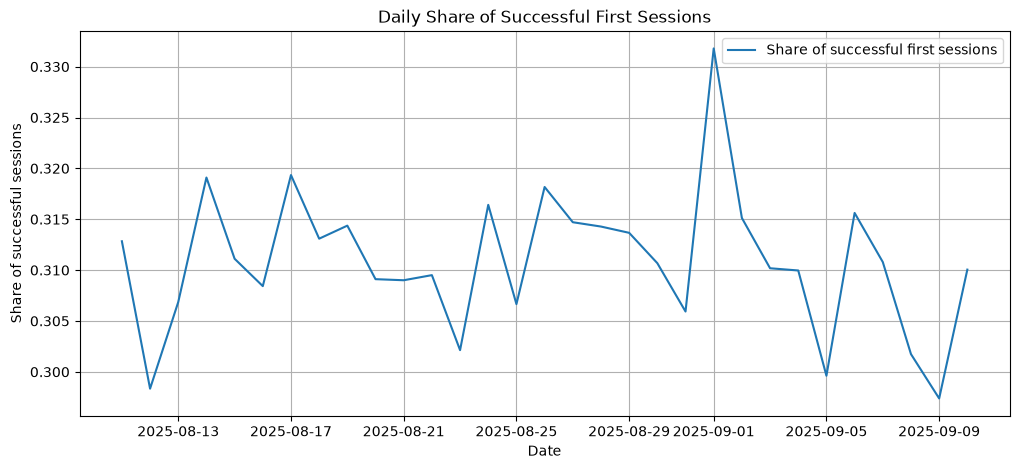

In [20]:
plt.figure(figsize=(12,5))

plt.plot(
    daily_good_sessions.index,
    daily_good_sessions['good_session_rate'],
    label='Share of successful first sessions'
)

plt.title('Daily Share of Successful First Sessions')
plt.xlabel('Date')
plt.ylabel('Share of successful sessions')

plt.grid()
plt.legend()

plt.show()

### 2. Test Preparation
Planning the test involves several important steps:

- Define the target metric.

- Calculate the required sample size.

- Estimate the required test duration based on current traffic.

#### 2.1. Sample Size Calculation

We will calculate the required number of users in each group using the `solve_power()` method of the `NormalIndPower` class.

Calculation parameters:

- significance level α — 0.05;
- probability of a Type II error β — 0.20;
- statistical power — 0.80;
- baseline share of successful first sessions — 0.30;
- minimum detectable effect — a 3% relative increase.

At a baseline rate of 30%, a 3% relative increase corresponds to an increase of 0.9 percentage points: from 30% to 30.9%.

Equal numbers of users are assumed in the control and treatment groups.

In [21]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

alpha = 0.05  # Significance level
beta = 0.2  # Probability of a Type II error
power = 1 - beta  # Statistical power
p = 0.3  # Assumed baseline share of successful first sessions
mde = 0.03 * p  # Absolute increase for a relative MDE of 3%
effect_size = proportion_effectsize(p, p + mde)

power_analysis = NormalIndPower()

sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Equal group sizes
)

print(f"Required sample size for each group: {int(sample_size)}")

Required sample size for each group: 41040


#### 2.2. A/B Test Duration Calculation

We will use the number of users in each sample and the average number of app users. We will calculate the test duration by dividing one by the other.

- Calculate the average number of unique app users per day.

- Determine the test duration based on the calculated sample sizes and the app's average daily traffic.

In [22]:
from math import ceil

avg_daily_users = sessions_history.groupby(
    'session_date'
).agg(
    users_count=('user_id', 'nunique')
)['users_count'].mean()

test_duration = ceil(sample_size * 2 / avg_daily_users)

print(f"The estimated A/B test duration at the current traffic level of {avg_daily_users} users per day is {test_duration} days")

The estimated A/B test duration at the current traffic level of 9907.363636363636 users per day is 9 days


### 3. A/B Test Monitoring

#### 3.1. User Allocation Check

We will use data from the first day of the A/B test to check the experiment launch.

We will load `sessions_project_test_part.csv` into the `sessions_test_part` DataFrame, calculate the number of unique users in groups A and B, and compare the group sizes.

We will calculate the percentage difference relative to the size of group A:

$$
P = 100 \cdot \frac{|A - B|}{A}
$$

We will display the number of users in each group in a bar chart.

In [23]:
sessions_test_part = pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_test_part.csv')

Calculate the number of unique users in each experiment group:

In [24]:
users_by_group = sessions_test_part.groupby(
    'test_group'
).agg(
    users_count=('user_id', 'nunique')
)
users_by_group

,users_count
test_group,
A,1477
B,1466


Extract the values for A and B:

In [25]:
group_a = users_by_group.loc['A', 'users_count']
group_b = users_by_group.loc['B', 'users_count']

Calculate the percentage difference:

In [26]:
percent_diff = 100 * abs(group_a - group_b) / group_a
percent_diff

np.float64(0.7447528774542993)

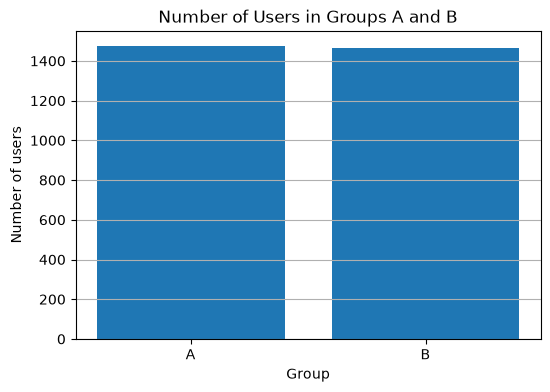

In [27]:
plt.figure(figsize=(6,4))

plt.bar(
    users_by_group.index,
    users_by_group['users_count']
)

plt.title('Number of Users in Groups A and B')
plt.xlabel('Group')
plt.ylabel('Number of users')

plt.grid(axis='y')

plt.show()

#### 3.2. User Overlap Check

We will check whether any users appear in both groups A and B.

An overlap would indicate a violation of user allocation: a participant should not be assigned to both the control and treatment groups.

In [28]:
list(set(sessions_test_part[
        sessions_test_part['test_group'] == 'A'
    ]['user_id']) & set(sessions_test_part[
        sessions_test_part['test_group'] == 'B'
    ]['user_id']))

[]

#### 3.3. Comparing User Distributions by Device

We will calculate the share of users for each device type separately for groups A and B.

We will create charts and compare the device composition of the groups to identify any noticeable differences.

In [29]:
# Calculate the number of unique users
devices_a = (
    sessions_test_part[
        sessions_test_part['test_group'] == 'A'
    ]
    .groupby('device')
    .agg(users_count=('user_id', 'nunique'))
)

# Calculate the share of users
devices_a['share'] = (
    devices_a['users_count']
    / devices_a['users_count'].sum()
)

# Calculate the number of unique users
devices_b = (
    sessions_test_part[
        sessions_test_part['test_group'] == 'B'
    ]
    .groupby('device')
    .agg(users_count=('user_id', 'nunique'))
)

# Calculate the share of users
devices_b['share'] = (
    devices_b['users_count']
    / devices_b['users_count'].sum()
)

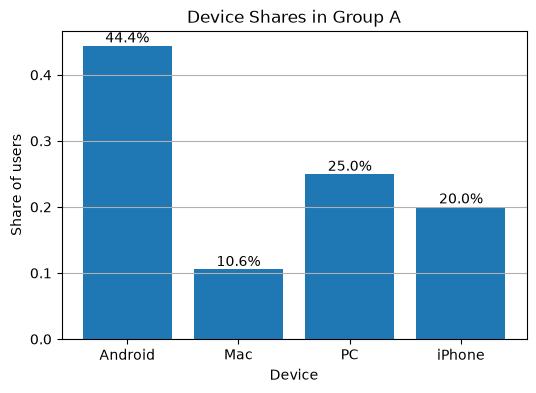

In [30]:
plt.figure(figsize=(6,4))

bars = plt.bar(
    devices_a.index,
    devices_a['share']
)

plt.title('Device Shares in Group A')
plt.xlabel('Device')
plt.ylabel('Share of users')

plt.grid(axis='y')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.1%}',
        ha='center',
        va='bottom'
    )

plt.show()

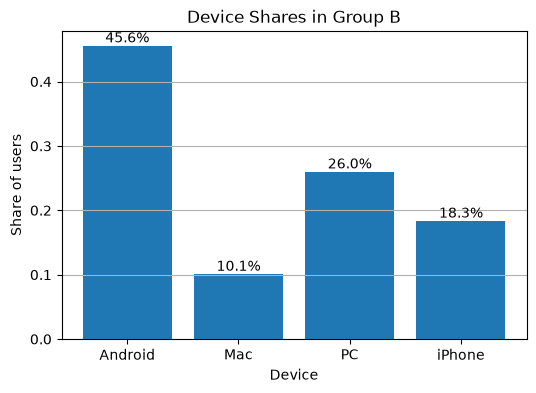

In [31]:
plt.figure(figsize=(6,4))

bars = plt.bar(
    devices_b.index,
    devices_b['share']
)

plt.title('Device Shares in Group B')
plt.xlabel('Device')
plt.ylabel('Share of users')

plt.grid(axis='y')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.1%}',
        ha='center',
        va='bottom'
    )

plt.show()

#### 3.4. Comparing User Distributions by Region

We will calculate the share of users from each region separately for groups A and B.

We will create pie charts and compare the regional composition of the groups to identify any noticeable differences.

In [32]:
# Calculate the number of unique users
regions_a = (
    sessions_test_part[
        sessions_test_part['test_group'] == 'A'
    ]
    .groupby('region')
    .agg(users_count=('user_id', 'nunique'))
)

# Calculate the share of users
regions_a['share'] = (
    regions_a['users_count']
    / regions_a['users_count'].sum()
)

# Calculate the number of unique users
regions_b = (
    sessions_test_part[
        sessions_test_part['test_group'] == 'B'
    ]
    .groupby('region')
    .agg(users_count=('user_id', 'nunique'))
)

# Calculate the share of users
regions_b['share'] = (
    regions_b['users_count']
    / regions_b['users_count'].sum()
)

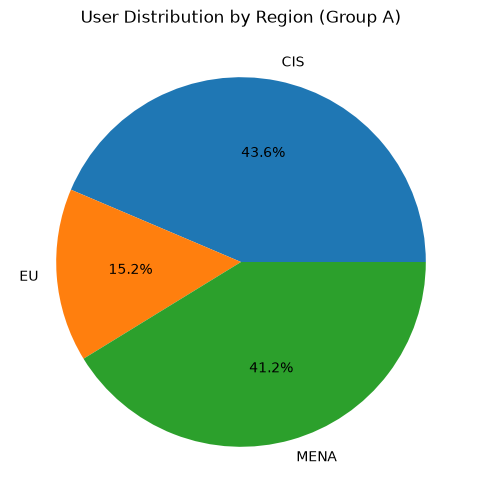

In [33]:
plt.figure(figsize=(6, 6))

plt.pie(
    regions_a['share'],
    labels=regions_a.index,
    autopct='%1.1f%%'
)

plt.title('User Distribution by Region (Group A)')

plt.show()

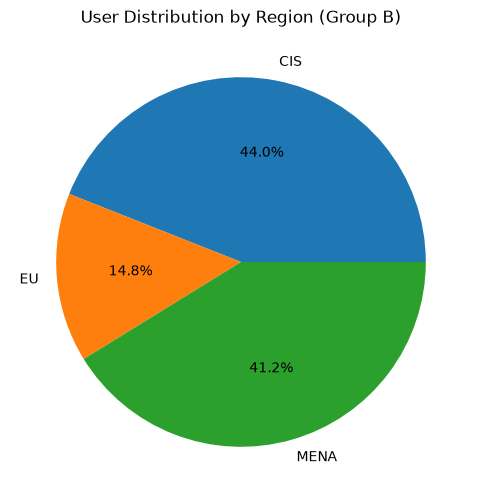

In [34]:
plt.figure(figsize=(6, 6))

plt.pie(
    regions_b['share'],
    labels=regions_b.index,
    autopct='%1.1f%%'
)

plt.title('User Distribution by Region (Group B)')

plt.show()

#### 3.5. A/B Test Validation Summary

We will summarize the checks of group sizes, user overlap, and distributions by device and region.

The A/B test validation identified no substantial issues in how the experiment was conducted.

The number of users in the treatment and control groups differs slightly: group A contains 1,477 users, and group B contains 1,466 users. The percentage difference between the groups is approximately 0.74%, indicating an even allocation of users between the groups.

The user overlap check established that users do not appear in both the treatment and control groups. This means that the samples are independent.

The device distributions in groups A and B are also almost identical. The shares of Android, PC, iPhone, and Mac users differ only slightly, so no substantial device imbalance is observed.

The regional distribution analysis also identified no critical differences. There are small differences in the shares of the CIS, EU, and MENA regions, but the overall distributions remain comparable between the groups.

Thus, groups A and B have been formed correctly: users are evenly allocated, the samples are independent, and no substantial differences in categorical characteristics were identified. The A/B test can be considered correctly launched, and its results can be used for further analysis.

### 4. A/B Test Results Analysis

We will analyze data for the full experiment period: calculate the key metric for the control and treatment groups, test the statistical significance of the differences, and formulate a recommendation on implementing the new algorithm.

#### 4.1. Loading Test Results and Calculating the Primary Metric

We will load data for the full A/B test period into the `sessions_test` DataFrame.

We will create the `good_session` column: a value of 1 indicates a session with four or more page views, and a value of 0 indicates a session with fewer page views.

In [35]:
sessions_test = pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_test.csv')

In [36]:
sessions_test['good_session'] = (
    sessions_test['page_counter'] >= 4
).astype(int)

#### 4.2. Hypothesis Formulation and Metric Definition

The **target metric** of the experiment is the share of successful first sessions. A session is considered successful if the user views four or more pages (good_session = 1). This metric allows us to assess how much the new recommendation algorithm increases user engagement and makes the content more interesting.

**Null hypothesis (H0)**: the new recommendation algorithm does not affect the share of successful first sessions. The share of successful first sessions is the same in groups A and B.

**Alternative hypothesis (H1)**: the new recommendation algorithm increases the share of successful first sessions. The share of successful first sessions is higher in the group using the new algorithm than in the control group.

**Proxy metrics** could include indicators of user engagement:
- average number of pages viewed per session;
- average session duration;
- number of pages viewed in the first days after app installation;
- share of users who return to the app after their first session.

**Guardrail metrics**:
- number of app errors and technical failures;
- app loading speed and response time;
- number of app uninstalls;
- user retention;
- share of users who disable notifications or stop using the app.

#### 4.3. Comparing the Share of Successful First Sessions

We will select the first sessions of users in the control and treatment groups.

For each group, we will calculate the share of successful first sessions, then determine the difference between group B and group A.

In [37]:
group_a = sessions_test[
    (sessions_test['test_group'] == 'A') & (sessions_test['session_number'] == 1)
]

group_b = sessions_test[
    (sessions_test['test_group'] == 'B') & (sessions_test['session_number'] == 1)
]

Calculate the share of successful sessions by group:

In [38]:
good_session_a = group_a['good_session'].mean()

good_session_b = group_b['good_session'].mean()

Calculate the difference in the metric:

In [39]:
difference = good_session_b - good_session_a
print(f'''
Share of successful first sessions in group A: {good_session_a:.1%}
Share of successful first sessions in group B: {good_session_b:.1%}
Difference between groups: {difference * 100:.2f} pp
''')


Share of successful first sessions in group A: 31.6%
Share of successful first sessions in group B: 31.5%
Difference between groups: -0.11 pp



#### 4.4. Testing the Statistical Significance of Differences

We will test whether there is statistically significant evidence that the new algorithm increases the share of successful first sessions.

We will use a one-sided Z-test to compare the two proportions. The significance level α is 0.05.

In [40]:
n_a = group_a.shape[0]
n_b = group_b.shape[0]

success_a = group_a['good_session'].sum()
success_b = group_b['good_session'].sum()

stat, p_value = proportions_ztest(
    [success_a, success_b],
    [n_a, n_b],
    alternative='smaller'
)

alpha = 0.05

print(f'pvalue={p_value}')

if p_value < alpha:
    print('The increase in the share of successful first sessions is statistically significant')
else:
    print('No statistically significant increase in the share of successful first sessions was detected')

pvalue=0.5783523649187868
No statistically significant increase in the share of successful first sessions was detected


#### 4.5. A/B Experiment Conclusion

An A/B test of the new recommendation algorithm was conducted as part of the experiment. Users in control group A interacted with the current version of the algorithm, while users in treatment group B interacted with the new version. The experiment included 2,943 users: 1,477 in group A and 1,466 in group B. The results were analyzed using data for the full A/B test period.

The key metric was the share of successful first sessions — sessions in which a user viewed four or more pages. The analysis showed a successful first-session rate of 31.6% in the control group and 31.5% in the treatment group. Thus, implementing the new recommendation algorithm led to a decrease in the key metric of 0.11 percentage points.

A Z-test comparing proportions was used to test the statistical significance of the differences. The resulting p-value was 0.578, which is above the chosen significance level of α = 0.05. Consequently, the observed change is not statistically significant, and the null hypothesis of no difference between the groups was accepted.

Based on the experiment results, we cannot conclude that the new recommendation algorithm improves the key metric. The observed difference was statistically insignificant, so the recommendation is to retain the current version of the algorithm and, if necessary, conduct another experiment with a refined hypothesis or a larger dataset.